# Measuring the effectiveness of quantization on SpeedyQ and vanilla Q-learning

In this notebook, we detail the code used to perform our study. Note that the sections may not follow the same order or structure as the report.


Our implementation uses [Gymnasium's Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). We also use [Joblib](https://joblib.readthedocs.io/en/stable/) to train multiple agents at the same time.

In [ ]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from joblib import Parallel, delayed
from timeit import default_timer

WINDOW_SIZE = 50
BINS = (4, 4, 10, 10)
QUANTIZATION_BITS = [4, 8, 16, None]
EPISODES = 3000
NUM_SEEDS = 16
SEEDS = list(range(200, 200 + NUM_SEEDS))

## Training environment

The first step is to define the agents as well as the quantization setup.

### Quantization

In [ ]:
class Quantizer:
    def __init__(self, bits, v_min, v_max, rng=None, d_type=np.uint16):
        self.v_min, self.v_max = float(v_min), float(v_max)
        self.levels = 2 ** bits
        self.step = (self.v_max - self.v_min) / (self.levels - 1)
        self.rng = rng if rng is not None else np.random.default_rng()
        self.d_type = d_type

    def quantize(self, x):
        scaled = (np.clip(x, self.v_min, self.v_max) - self.v_min) / self.step

        # Stochastic rounding
        floor = np.floor(scaled)
        level = floor + (self.rng.random(np.shape(scaled)) < scaled - floor)

        return level.astype(self.d_type)

    def get_value(self, idx):
        return self.v_min + idx * self.step

### Agents

The following class represents a generic agent : it loads the environment, sets up quantization, and implements a generic training loop.

In [ ]:
class BaseCartPoleLearner(ABC):
    """ Abstract base class for CartPole learners. """

    def __init__(self, episodes=3000, gamma=0.99, failure_penalty=-100,
                 epsilon=1.0, epsilon_decay=0.994, min_epsilon=0.00003,
                 bins=(4, 4, 10, 10), seed=None,
                 quantize_bits=None, q_max=100.0,
                 print_progress=True):
        self.env = gym.make('CartPole-v1')
        self.episodes = episodes
        self.gamma = gamma
        self.failure_penalty = failure_penalty
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon
        self.print_progress = print_progress

        self.seed = seed
        self.rng = np.random.default_rng(seed)
        if self.seed is not None:
            np.random.seed(self.seed)
            self.env.action_space.seed(self.seed)

        # Discretization
        self.n_bins = bins
        self.bins = [
            np.linspace(-4.8, 4.8, self.n_bins[0] - 1),
            np.linspace(-3.0, 3.0, self.n_bins[1] - 1),
            np.linspace(-0.418, 0.418, self.n_bins[2] - 1),
            np.linspace(-3.0, 3.0, self.n_bins[3] - 1)
        ]

        # Quantization setup
        if quantize_bits is not None:
            if quantize_bits <= 8:
                d_type = np.uint8
            elif quantize_bits <= 16:
                d_type = np.uint16
            elif quantize_bits <= 32:
                d_type = np.uint32
            else:
                d_type = np.uint64

            self.quantizer = Quantizer(
                bits=quantize_bits,
                v_min=self.failure_penalty,
                v_max=q_max,
                rng=self.rng,
                d_type=d_type)

            self.Q = np.ones(self.n_bins + (self.env.action_space.n,), dtype=d_type) * self.quantizer.quantize(0.0)
            self.Q_old = np.ones(self.Q.shape, dtype=d_type) * self.quantizer.quantize(0.0)

        else:
            self.quantizer = None
            self.Q = np.zeros(self.n_bins + (self.env.action_space.n,), dtype=np.float64)
            self.Q_old = np.zeros_like(self.Q, dtype=np.float64)

        self.state_action_counts = np.zeros_like(self.Q, dtype=np.int32)

        self.rewards_history = []
        self.bellman_errors_history = []


    """ Discretize the continuous state into discrete bins """
    def discretize_state(self, state):
        discretized = []
        for i in range(len(state)):
            discretized.append(np.digitize(state[i], self.bins[i]))
        return tuple(discretized)

    """ Choose an action using epsilon-greedy policy """
    def choose_action(self, state_idx):
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.Q[state_idx])

    """ Quantize the Q-table if a quantizer is provided. """
    def _quantize_q_table(self):
        if self.quantizer is not None:
            self.Q = self.quantizer.quantize(self.Q)

    def get_reward_history(self):
        return self.rewards_history

    def get_state_action_counts(self):
        return self.state_action_counts

    """ Method informing the user about good convergence or not"""
    def is_converged(self, window_size=150, threshold=470):
        if len(self.rewards_history) < window_size:
            return False
        moving_avg = np.mean(self.rewards_history[-window_size:])
        return moving_avg >= threshold

    @abstractmethod
    def _update_q_table(self, state_idx, action, reward, next_state_idx, done):
        """ Abstract method: must be implemented for each specific algorithm. """
        pass

    @abstractmethod
    def _update_hyperparameters(self, episode):
        """ Abstract method: must be implemented by the subclass to update hyperparameters (e.g., alpha). """
        pass

    def train(self):
        self.rewards_history = []

        if self.seed is not None:
            self.env.reset(seed=self.seed)
            seed_text = f" Seed: {self.seed} | "
        else:
            seed_text = ""

        print(seed_text + "Starting training...")

        for episode in range(self.episodes):
            state, _ = self.env.reset()
            state_idx = self.discretize_state(state)
            total_reward = 0

            episode_errors = []

            while True:
                action = self.choose_action(state_idx)

                next_state, reward, terminated, truncated, _ = self.env.step(action)
                next_state_idx = self.discretize_state(next_state)
                done = terminated or truncated

                # Update state-action counts for exploration bonuses or analysis.
                self.state_action_counts[state_idx + (action,)] += 1

                # Inflict a severe penalty if the episode ends due to agent failure.
                if terminated:
                    reward = self.failure_penalty

                # Specific update method for each algorithm.
                bellman_error = self._update_q_table(state_idx, action, reward, next_state_idx, done)
                episode_errors.append(bellman_error)

                state_idx = next_state_idx
                total_reward += reward

                if done:
                    break

            # Update the hyperparameters.
            self._update_hyperparameters(episode)
            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

            self.rewards_history.append(total_reward)
            self.bellman_errors_history.append(np.mean(episode_errors))

            if self.print_progress and (episode + 1) % 500 == 0:
                avg_reward = np.mean(self.rewards_history[-100:])
                print(seed_text + f"Episode {episode + 1}/{self.episodes} | Average Reward : {avg_reward:.2f}")

        print(seed_text + "Training completed!")
        self.env.close()

Now we can instantiate the specific algorithms. First, vanilla Q-learning :

In [ ]:
class VanillaQLearningCartPole(BaseCartPoleLearner):
    """ Implémentation spécifique du Vanilla Q-Learning """

    def __init__(self, episodes=3000, alpha=0.1, gamma=0.99, failure_penalty=-100,
                 epsilon=1.0, epsilon_decay=0.994, min_epsilon=0.00003,
                 bins=(4, 4, 10, 10), seed=None,
                 quantize_bits=None, q_max=100.0,
                 print_progress=True):

        self.alpha = alpha

        super().__init__(
            episodes=episodes,
            gamma=gamma,
            failure_penalty=failure_penalty,
            epsilon=epsilon,
            epsilon_decay=epsilon_decay,
            min_epsilon=min_epsilon,
            bins=bins,
            seed=seed,
            quantize_bits=quantize_bits,
            q_max=q_max,
            print_progress=print_progress
        )


    def _update_q_table(self, state_idx, action, reward, next_state_idx, done):
        if self.quantizer is None:
            max_next_Q = np.max(self.Q[next_state_idx])
            current_q = self.Q[state_idx + (action,)]
        else:
            max_next_Q = self.quantizer.get_value(np.max(self.Q[next_state_idx]))
            current_q = self.quantizer.get_value(self.Q[state_idx + (action,)])

        TQ = reward + self.gamma * max_next_Q * (not done)

        new_q = current_q + self.alpha * (TQ - current_q)

        self.Q[state_idx + (action,)] = new_q if self.quantizer is None else self.quantizer.quantize(new_q)

        # Compute the Bellman error for later analysis.
        return abs(current_q - TQ)

    def _update_hyperparameters(self, episode):
        return

    def size_in_bytes(self):
        return self.Q.nbytes

Then, the *SpeedyQ* algorithm :

In [ ]:
class SpeedyQLearningCartPole(BaseCartPoleLearner):
    """ Implémentation spécifique du Vanilla Q-Learning """

    def __init__(self, episodes=3000, alpha_decay=0.002, alpha_min=0.002, gamma=0.99, failure_penalty=-100,
                 epsilon=1.0, epsilon_decay=0.994, min_epsilon=0.00003,
                 bins=(4, 4, 10, 10), seed=None,
                 quantize_bits=None, q_max=100.0,
                 print_progress=True):

        self.alpha_decay = alpha_decay
        self.alpha_min = alpha_min
        # Starting learning rate value.
        self.alpha = 1.0

        super().__init__(
            episodes=episodes,
            gamma=gamma,
            failure_penalty=failure_penalty,
            epsilon=epsilon,
            epsilon_decay=epsilon_decay,
            min_epsilon=min_epsilon,
            bins=bins,
            seed=seed,
            quantize_bits=quantize_bits,
            q_max=q_max,
            print_progress=print_progress
        )


    def _update_q_table(self, state_idx, action, reward, next_state_idx, done):

        if self.quantizer is None:
            max_next_Q = np.max(self.Q[next_state_idx])
            max_next_Q_old = np.max(self.Q_old[next_state_idx])
            current_q = self.Q[state_idx + (action,)]
        else:
            max_next_Q = self.quantizer.get_value(np.max(self.Q[next_state_idx]))
            max_next_Q_old = self.quantizer.get_value(np.max(self.Q_old[next_state_idx]))
            current_q = self.quantizer.get_value(self.Q[state_idx + (action,)])

        TQ = reward + self.gamma * max_next_Q * (not done)
        TQ_old = reward + self.gamma * max_next_Q_old * (not done)

        new_q = current_q + self.alpha * (TQ_old - current_q) + (1 - self.alpha) * (TQ - TQ_old)

        self.Q_old[state_idx + (action,)] = self.Q[state_idx + (action,)]
        self.Q[state_idx + (action,)] = new_q if self.quantizer is None else self.quantizer.quantize(new_q)

        # Return Bellman error.
        return abs(current_q - TQ)

    def _update_hyperparameters(self, episode):
        self.alpha = max(1.0 / (1.0 + episode * self.alpha_decay), self.alpha_min)

    def size_in_bytes(self):
        return self.Q.nbytes + self.Q_old.nbytes

We also define a helper method that will be useful for visualization :

In [ ]:
""" Method to compute the moving average of rewards for better visualization. """
def moving_average(data, window_size=WINDOW_SIZE):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

## Simple test

We start by simply assessing the convergence of the two algorithms over one seed.

In [ ]:
# Vanilla training, for the default parameters, 3000 episodes are sufficient.
print("Vanilla Q-Learning agent :")
global_vanilla_agent = VanillaQLearningCartPole(episodes=3000)
global_vanilla_agent.train()
vanilla_rewards_history = global_vanilla_agent.get_reward_history()

if not global_vanilla_agent.is_converged():
    print("The results could be better. Consider changing the random seed (or simply retrying if no seed was specified)")
else:
    print("The results look good! The agent is likely converging to a good policy.")

Vanilla Q-Learning agent :
Starting training...
Episode 500/3000 | Average Reward : 244.90
Episode 1000/3000 | Average Reward : 127.79
Episode 1500/3000 | Average Reward : 487.78
Episode 2000/3000 | Average Reward : 500.00
Episode 2500/3000 | Average Reward : 500.00
Episode 3000/3000 | Average Reward : 500.00
Training completed!
The results look good! The agent is likely converging to a good policy.


In [ ]:
print("\nSpeedy Q-Learning agent :")
global_speedy_agent = SpeedyQLearningCartPole(episodes=3000)
global_speedy_agent.train()
speedy_rewards_history = global_speedy_agent.get_reward_history()

if not global_speedy_agent.is_converged():
    print("The results could be better. Consider changing the random seed (or simply retrying if no seed was specified)")
else:
    print("The results look good! The agent is likely converging to a good policy.")


Speedy Q-Learning agent :
Starting training...
Episode 500/3000 | Average Reward : 65.69
Episode 1000/3000 | Average Reward : 144.12
Episode 1500/3000 | Average Reward : 315.42
Episode 2000/3000 | Average Reward : 487.07
Episode 2500/3000 | Average Reward : 500.00
Episode 3000/3000 | Average Reward : 500.00
Training completed!
The results look good! The agent is likely converging to a good policy.


Here are the results on a same plot. (Making use of a moving average with a window of 50).

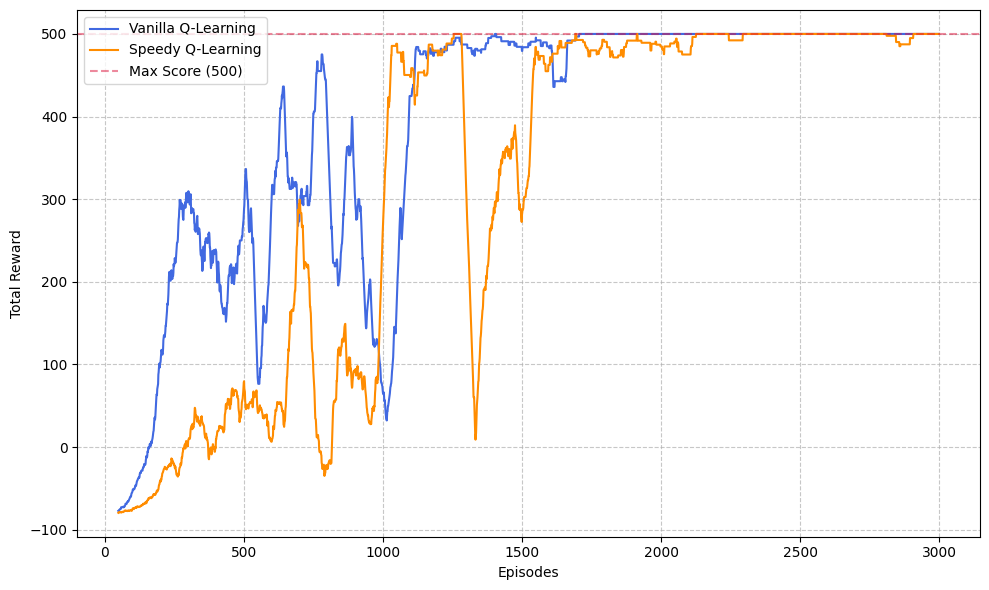

In [ ]:
# Comparison plot of the moving averages
plt.figure(figsize=(10, 6))
moving_avg_vanilla = moving_average(vanilla_rewards_history)
moving_avg_speedy = moving_average(speedy_rewards_history)

plt.plot(range(WINDOW_SIZE - 1, len(vanilla_rewards_history)), moving_avg_vanilla, label='Vanilla Q-Learning', color='royalblue')
plt.plot(range(WINDOW_SIZE - 1, len(speedy_rewards_history)), moving_avg_speedy, label='Speedy Q-Learning', color='darkorange')
plt.axhline(y=500, color='crimson', linestyle='--', alpha=0.5, label='Max Score (500)')
plt.xlabel('Episodes')
plt.ylabel('Total Reward')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Experiments

Now that everything is set up, we can proceed to generating everything we need.

To be able to run multiple training loops quickly, we make use of the Joblib library for parallel processing.

In [ ]:
def run_one_seed_vanilla(params):
    start = default_timer()
    agent = VanillaQLearningCartPole(**params)
    agent.train()
    elapsed = default_timer() - start
    return agent, elapsed

def run_one_seed_speedy(params):
    start = default_timer()
    agent = SpeedyQLearningCartPole(**params)
    agent.train()
    elapsed = default_timer() - start
    return agent, elapsed

### Convergence

We start by a training the agents (16 for each algorithm) and plotting convergence.


4-bits quantization over 16 seeds
Training Vanilla Q-Learning in parallel...
 Seed: 203 | Starting training... Seed: 201 | Starting training...

 Seed: 206 | Starting training...
 Seed: 204 | Starting training...
 Seed: 202 | Starting training...
 Seed: 205 | Starting training...
 Seed: 200 | Starting training...
 Seed: 207 | Starting training...
 Seed: 206 | Training completed!
 Seed: 208 | Starting training...
 Seed: 203 | Training completed!
 Seed: 209 | Starting training...
 Seed: 207 | Training completed!
 Seed: 210 | Starting training...
 Seed: 200 | Training completed!
 Seed: 211 | Starting training...
 Seed: 204 | Training completed!
 Seed: 212 | Starting training...
 Seed: 201 | Training completed!
 Seed: 213 | Starting training...
 Seed: 202 | Training completed!
 Seed: 214 | Starting training...
 Seed: 205 | Training completed!
 Seed: 215 | Starting training...
 Seed: 209 | Training completed!
 Seed: 208 | Training completed!
 Seed: 211 | Training completed!
 Seed: 212 | Tr

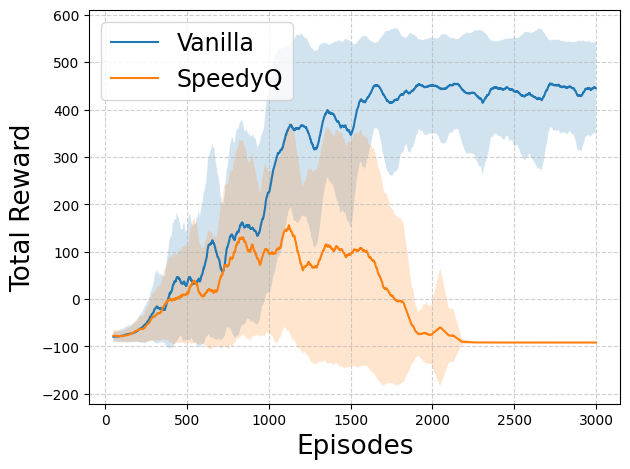


8-bits quantization over 16 seeds
Training Vanilla Q-Learning in parallel...
 Seed: 200 | Starting training...
 Seed: 201 | Starting training...
 Seed: 202 | Starting training...
 Seed: 203 | Starting training...
 Seed: 204 | Starting training...
 Seed: 205 | Starting training...
 Seed: 206 | Starting training...
 Seed: 207 | Starting training...
 Seed: 206 | Training completed!
 Seed: 208 | Starting training...
 Seed: 201 | Training completed!
 Seed: 209 | Starting training...
 Seed: 203 | Training completed!
 Seed: 210 | Starting training...
 Seed: 205 | Training completed!
 Seed: 211 | Starting training...
 Seed: 207 | Training completed!
 Seed: 212 | Starting training...
 Seed: 204 | Training completed!
 Seed: 213 | Starting training...
 Seed: 200 | Training completed!
 Seed: 214 | Starting training...
 Seed: 202 | Training completed!
 Seed: 215 | Starting training...
 Seed: 208 | Training completed!
 Seed: 209 | Training completed!
 Seed: 210 | Training completed!
 Seed: 213 | Tr

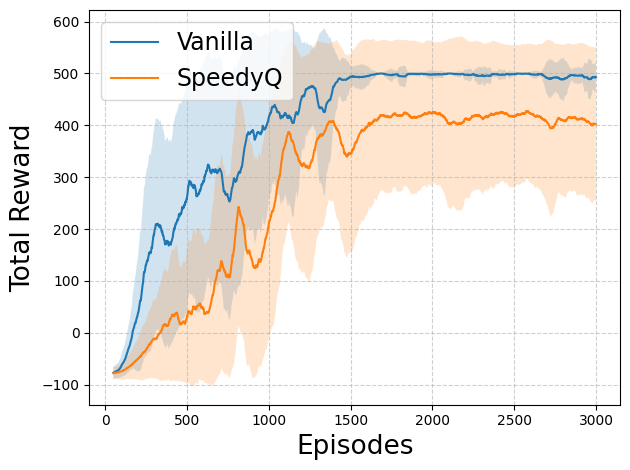


16-bits quantization over 16 seeds
Training Vanilla Q-Learning in parallel...
 Seed: 200 | Starting training...
 Seed: 201 | Starting training...
 Seed: 202 | Starting training...
 Seed: 203 | Starting training...
 Seed: 204 | Starting training...
 Seed: 205 | Starting training...
 Seed: 206 | Starting training...
 Seed: 207 | Starting training...
 Seed: 200 | Training completed!
 Seed: 208 | Starting training...
 Seed: 201 | Training completed!
 Seed: 209 | Starting training...
 Seed: 204 | Training completed!
 Seed: 210 | Starting training...
 Seed: 203 | Training completed!
 Seed: 211 | Starting training...
 Seed: 205 | Training completed!
 Seed: 212 | Starting training...
 Seed: 202 | Training completed!
 Seed: 213 | Starting training...
 Seed: 207 | Training completed!
 Seed: 214 | Starting training...
 Seed: 206 | Training completed!
 Seed: 215 | Starting training...
 Seed: 208 | Training completed!
 Seed: 209 | Training completed!
 Seed: 210 | Training completed!
 Seed: 211 | T

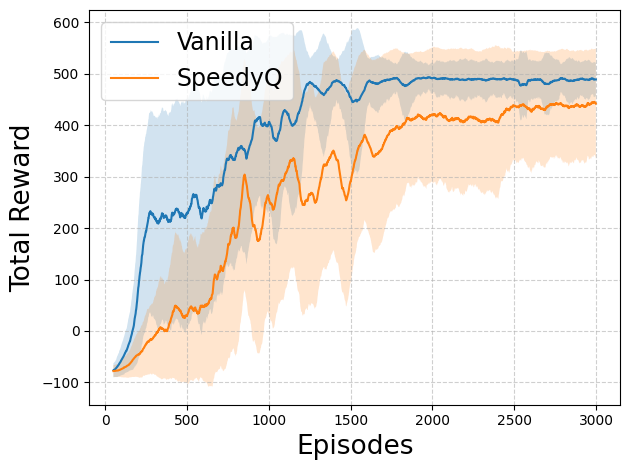


Full precision over 16 seeds
Training Vanilla Q-Learning in parallel...
 Seed: 200 | Starting training...
 Seed: 201 | Starting training...
 Seed: 203 | Starting training...
 Seed: 202 | Starting training...
 Seed: 204 | Starting training...
 Seed: 205 | Starting training...
 Seed: 206 | Starting training...
 Seed: 207 | Starting training...
 Seed: 200 | Training completed!
 Seed: 208 | Starting training...
 Seed: 203 | Training completed!
 Seed: 209 | Starting training...
 Seed: 204 | Training completed!
 Seed: 210 | Starting training...
 Seed: 205 | Training completed!
 Seed: 211 | Starting training...
 Seed: 207 | Training completed!
 Seed: 212 | Starting training...
 Seed: 201 | Training completed!
 Seed: 213 | Starting training...
 Seed: 206 | Training completed!
 Seed: 214 | Starting training...
 Seed: 202 | Training completed!
 Seed: 215 | Starting training...
 Seed: 208 | Training completed!
 Seed: 209 | Training completed!
 Seed: 213 | Training completed!
 Seed: 210 | Trainin

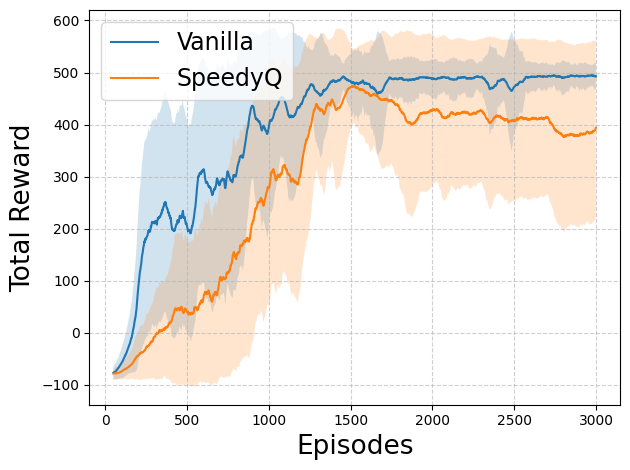

In [ ]:
# Initialize a 2x2 grid of subplots
timing_results = []

# Store all agents by quantization level
all_vanilla_agents = {}
all_speedy_agents = {}

for i, bits in enumerate(QUANTIZATION_BITS):
    label = f"{bits}-bit" if bits else "Full precision"
    if bits is None:
        print(f"\nFull precision over {NUM_SEEDS} seeds")
    else:
        print(f"\n{bits}-bits quantization over {NUM_SEEDS} seeds")
    plt.xlabel("Episodes", fontsize=19)
    plt.ylabel("Total Reward", fontsize=19)
    plt.grid(True, linestyle="--", alpha=0.6)

    # Parameter dictionaries for each seed
    params_list = [
        {
            'episodes': EPISODES,
            'bins': BINS,
            'quantize_bits': bits,
            'seed': seed,
            'print_progress': False
        }
        for seed in SEEDS
    ]

    print("Training Vanilla Q-Learning in parallel...")
    vanilla_results = Parallel(n_jobs=-1)(
        delayed(run_one_seed_vanilla)(params) for params in params_list
    )
    vanilla_agents = [r[0] for r in vanilla_results]
    vanilla_times = [r[1] for r in vanilla_results]
    print(f"  Per-seed times: {[f'{t:.2f}s' for t in vanilla_times]}")
    print(f"  Mean: {np.mean(vanilla_times):.2f}s | Std: {np.std(vanilla_times):.2f}s")
    vanilla_histories = np.array([agent.get_reward_history() for agent in vanilla_agents])

    print("Training Speedy Q-Learning in parallel...")
    speedy_results = Parallel(n_jobs=-1)(
        delayed(run_one_seed_speedy)(params) for params in params_list
    )
    speedy_agents = [r[0] for r in speedy_results]
    speedy_times = [r[1] for r in speedy_results]
    print(f"  Per-seed times: {[f'{t:.2f}s' for t in speedy_times]}")
    print(f"  Mean: {np.mean(speedy_times):.2f}s | Std: {np.std(speedy_times):.2f}s")
    speedy_histories = np.array([agent.get_reward_history() for agent in speedy_agents])

    # Store agents by quantization level
    all_vanilla_agents[bits] = vanilla_agents
    all_speedy_agents[bits] = speedy_agents

    timing_results.append({
        'config': label,
        'vanilla_mean': np.mean(vanilla_times),
        'vanilla_std': np.std(vanilla_times),
        'speedy_mean': np.mean(speedy_times),
        'speedy_std': np.std(speedy_times)
    })

    vanilla_avg = np.mean(vanilla_histories, axis=0)
    speedy_avg = np.mean(speedy_histories, axis=0)

    vanilla_std = np.std(vanilla_histories, axis=0)
    speedy_std = np.std(speedy_histories, axis=0)

    moving_avg_vanilla = moving_average(vanilla_avg)
    moving_avg_speedy = moving_average(speedy_avg)

    moving_std_vanilla = moving_average(vanilla_std)
    moving_std_speedy = moving_average(speedy_std)

    x_axis = range(WINDOW_SIZE - 1, len(vanilla_avg))

    plt.plot(x_axis, moving_avg_vanilla, label='Vanilla')
    plt.plot(x_axis, moving_avg_speedy, label='SpeedyQ')

    # Fill the standard deviation boundaries for visual variance context
    plt.fill_between(x_axis,
                    moving_avg_vanilla - moving_std_vanilla,
                    moving_avg_vanilla + moving_std_vanilla,
                    alpha=0.2)

    plt.fill_between(x_axis,
                    moving_avg_speedy - moving_std_speedy,
                    moving_avg_speedy + moving_std_speedy,
                    alpha=0.2)

    plt.legend(loc="upper left", fontsize=17)

    plt.tight_layout()
    plt.show()

### Success rate

Another important metric we can look at is the success rate, which we define to be the rate of runs that have attained 490 (98% of 500) points among the last 150 runs.

In [ ]:
print("\n" + "="*80)
print("SUCCESS RATE ANALYSIS (Convergence Rate)")
print("="*80)
print(f"{'Config':<15} {'Vanilla':<20} {'SpeedyQ':<20}")
print(f"{'':15} {'Converged/Total':<10} {'Rate':<10} {'Converged/Total':<10} {'Rate':<10}")
print("-"*80)

for bits in QUANTIZATION_BITS:
    label = f"{bits}-bit" if bits else "Full precision"

    # Count converged agents for Vanilla
    vanilla_converged = sum(1 for agent in all_vanilla_agents[bits] if agent.is_converged(window_size=150, threshold=490))
    vanilla_total = len(all_vanilla_agents[bits])
    vanilla_rate = vanilla_converged / vanilla_total * 100

    # Count converged agents for SpeedyQ
    speedy_converged = sum(1 for agent in all_speedy_agents[bits] if agent.is_converged(window_size=150, threshold=490))
    speedy_total = len(all_speedy_agents[bits])
    speedy_rate = speedy_converged / speedy_total * 100

    print(f"{label:<15} {vanilla_converged}/{vanilla_total:<9} {vanilla_rate:>6.1f}%    {speedy_converged}/{speedy_total:<9} {speedy_rate:>6.1f}%")

print("="*80)


SUCCESS RATE ANALYSIS (Convergence Rate)
Config          Vanilla              SpeedyQ             
                Converged/Total Rate       Converged/Total Rate      
--------------------------------------------------------------------------------
4-bit           7/16          43.8%    0/16           0.0%
8-bit           11/16          68.8%    7/16          43.8%
16-bit          12/16          75.0%    7/16          43.8%
Full precision  13/16          81.2%    7/16          43.8%


### Computation time

Since with quantization the number of possible values is now discrete, it isn't unreasonable to expect faster training runtime. We empirically test this hypothesis.

In [ ]:
print("\n" + "="*80)
print("TIMING SUMMARY (per-seed mean)")
print("="*80)
print(f"{'Config':<15} {'Vanilla Mean':<15} {'Vanilla Std':<15} {'SpeedyQ Mean':<15} {'SpeedyQ Std'}")
print("-"*80)
for result in timing_results:
    print(f"{result['config']:<15} {result['vanilla_mean']:<15.2f} {result['vanilla_std']:<15.2f} {result['speedy_mean']:<15.2f} {result['speedy_std']:.2f}")


TIMING SUMMARY (per-seed mean)
Config          Vanilla Mean    Vanilla Std     SpeedyQ Mean    SpeedyQ Std
--------------------------------------------------------------------------------
4-bit           33.34           2.76            10.28           4.88
8-bit           39.29           3.38            35.03           5.84
16-bit          38.55           4.27            33.83           6.27
Full precision  27.97           3.33            25.95           2.88


Clearly, our intuition was wrong. It appears that the overhead introduced by quantization is huge.

### Memory usage

The main objective of quantization is to reduce the memory taken by the Q-table. The following code compares the theoretical size that would have a Q-table in memory, against the actual one in our implementation.

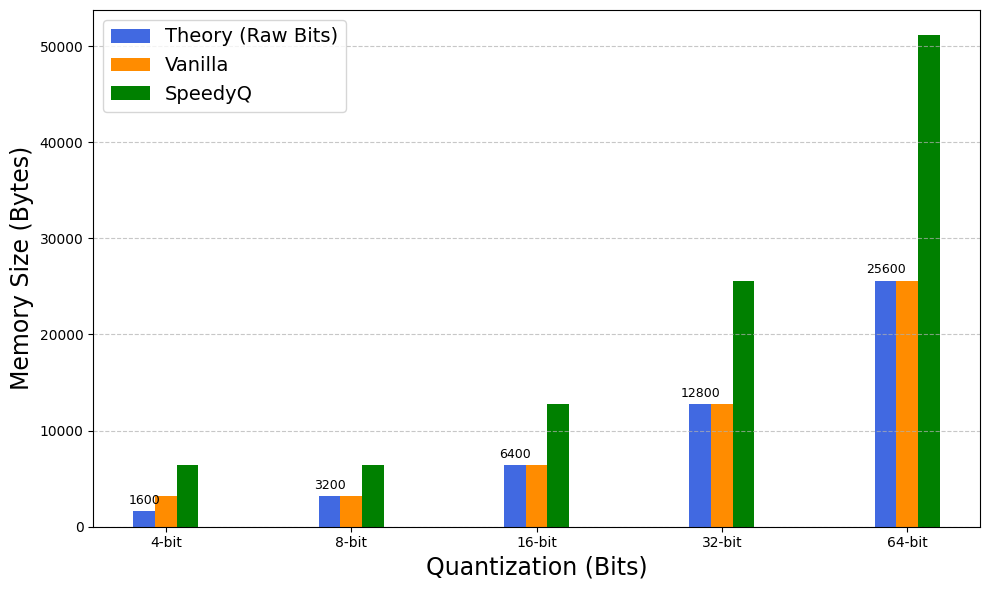

In [ ]:
ACTIONS = 2
QUANTIZATION_BITS_MEMORY = [4, 8, 16, 32, 64]  # Added 32-bit as the standard unquantized baseline

# Calculate total number of Q-values in the table
num_values = np.prod(BINS) * ACTIONS

theory_bytes = []
implementation_bytes_vanilla = []
implementation_bytes_speedy = []

for bits in QUANTIZATION_BITS_MEMORY:
    # Theoretical memory usage (bytes)
    theory = (num_values * bits) / 8.0
    theory_bytes.append(theory)

    # Implementation Memory (Bytes)
    agent_vanilla = VanillaQLearningCartPole(bins=BINS, quantize_bits=bits)
    agent_speedy = SpeedyQLearningCartPole(bins=BINS, quantize_bits=bits)

    implementation_bytes_vanilla.append(agent_vanilla.size_in_bytes())
    implementation_bytes_speedy.append(agent_speedy.size_in_bytes())

# Plotting the results
x_indices = np.arange(len(QUANTIZATION_BITS_MEMORY))
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))


bars_theory = ax.bar(x_indices-width/3, theory_bytes, width/3, label='Theory (Raw Bits)', color='royalblue')
bars_impl_vanilla = ax.bar(x_indices, implementation_bytes_vanilla, width/3, label='Vanilla', color='darkorange')
bars_impl_speedy = ax.bar(x_indices+width/3, implementation_bytes_speedy, width/3, label='SpeedyQ', color='green')

# Formatting the plot
ax.set_xlabel('Quantization (Bits)', fontsize=17)
ax.set_ylabel('Memory Size (Bytes)', fontsize=17)
ax.set_xticks(x_indices)
ax.set_xticklabels([f"{b}-bit" for b in QUANTIZATION_BITS_MEMORY])
ax.legend(fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact value annotations on top of the bars
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

annotate_bars(bars_theory)

plt.tight_layout()
plt.show()

Notice that for 2 and 4 bits, the theory is better: this is because our implementation uses numpy's `uint8` for values of bits lower than or equal to 8. Notice also that SpeedyQ is always two times bigger than Vanilla: this is because it uses two tables (the current one and the previous one) for momentum.

### Training Error (Bellman Absolute Error)

The plots below show the Bellman absolute error of the runs, which measures the magnitude of the discrepancy between the agent's current prediction and the updated target, defined mathematically as:

$$|\Delta_t| = \left| Q(s_t, a_t) - \left( r_t + \gamma \max_{a} Q(s_{t+1}, a) \right) \right|$$

4-bits quantization


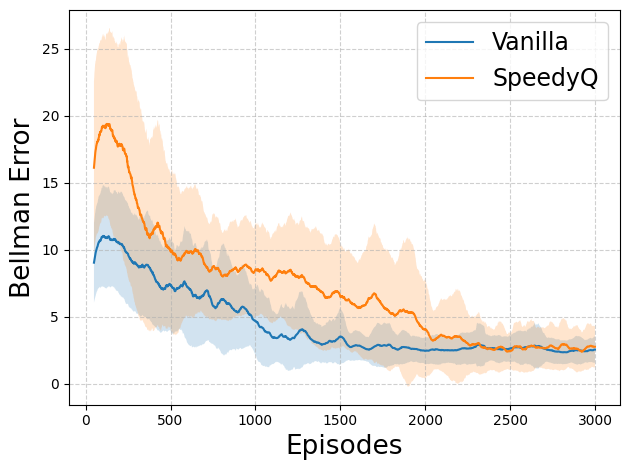

8-bits quantization


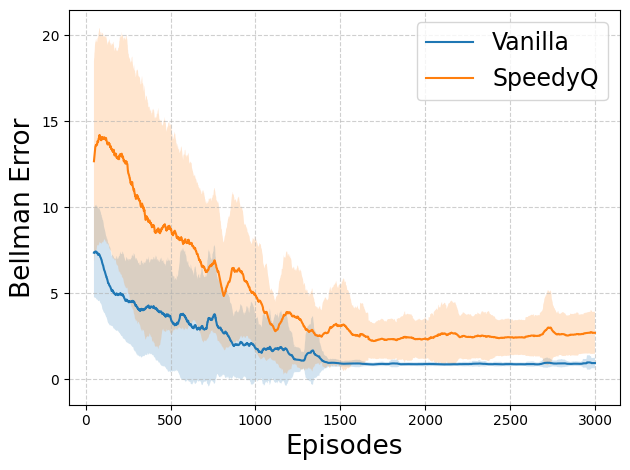

16-bits quantization


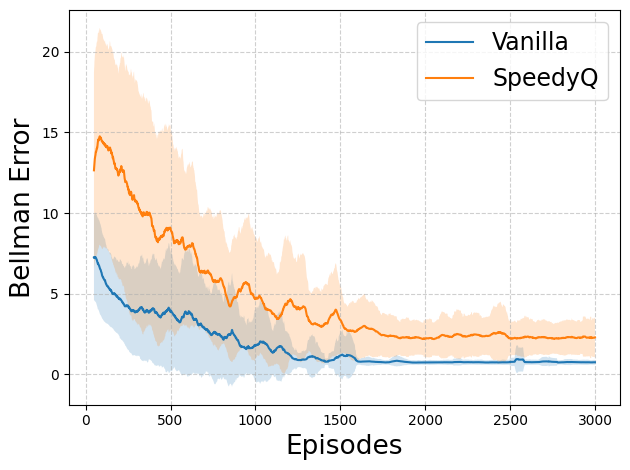

Full precision


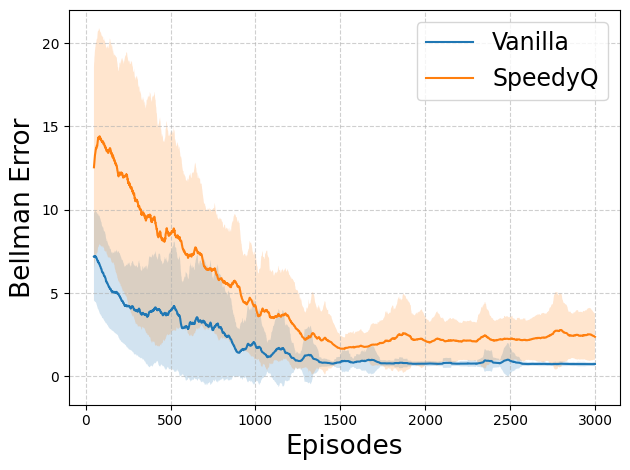

In [ ]:

for i, bits in enumerate(QUANTIZATION_BITS):
    if bits is None:
        print("Full precision")
    else:
        print(f"{bits}-bits quantization")
    plt.xlabel("Episodes", fontsize=19)
    plt.ylabel("Bellman Error", fontsize=19)
    plt.grid(True, linestyle="--", alpha=0.6)

    errors_vanilla = []
    for agent in all_vanilla_agents[bits]:
        errors_vanilla.append(agent.bellman_errors_history)
    errors_speedy = []
    for agent in all_speedy_agents[bits]:
        errors_speedy.append(agent.bellman_errors_history)

    # Calculate the Means
    vanilla_avg = np.mean(errors_vanilla, axis=0)
    speedy_avg = np.mean(errors_speedy, axis=0)

    # Calculate Standard Deviations
    vanilla_std = np.std(errors_vanilla, axis=0)
    speedy_std = np.std(errors_speedy, axis=0)

    # Apply the moving average
    moving_avg_vanilla = moving_average(vanilla_avg)
    moving_avg_speedy = moving_average(speedy_avg)

    moving_std_vanilla = moving_average(vanilla_std)
    moving_std_speedy = moving_average(speedy_std)

    # Plot
    x_axis = range(WINDOW_SIZE - 1, len(vanilla_avg))

    plt.plot(x_axis, moving_avg_vanilla, label='Vanilla')
    plt.plot(x_axis, moving_avg_speedy, label='SpeedyQ')

    # Fill the standard deviation boundaries for visual variance context
    plt.fill_between(x_axis,
                    moving_avg_vanilla - moving_std_vanilla,
                    moving_avg_vanilla + moving_std_vanilla,
                    alpha=0.2)

    plt.fill_between(x_axis,
                    moving_avg_speedy - moving_std_speedy,
                    moving_avg_speedy + moving_std_speedy,
                    alpha=0.2)

    plt.legend(loc="upper right", fontsize = 17)


    plt.tight_layout()
    plt.show()

### State Visitation Analysis

The following heatmap shows the visitation counts of a trained Vanilla agent with 8-bits quantization.

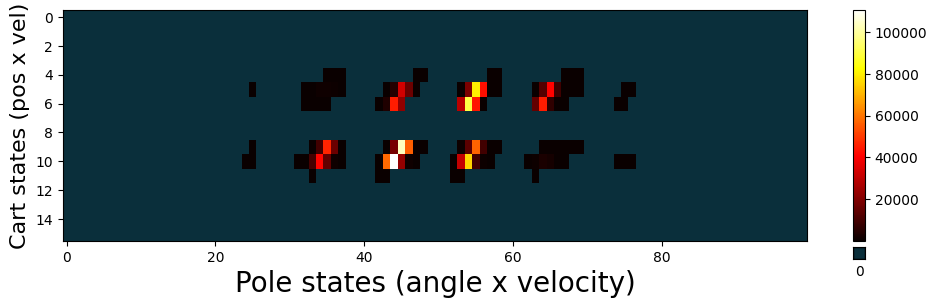

7% of cells visited; top 2.5% of cells hold 99% of all visits


In [ ]:
vanilla_8bit = all_vanilla_agents[8]

counts = vanilla_8bit[0].state_action_counts.sum(axis=4)
counts_2d = counts.reshape(4*4, 10*10)  # (16, 100)

# Mask zero values so they get a distinct color
counts_masked = np.ma.masked_where(counts_2d == 0, counts_2d)

fig, ax = plt.subplots(figsize=(12, 3))
cmap = plt.cm.hot.copy()
cmap.set_bad(color='#0a2f3b')  # Dark teal for unvisited cells

im = ax.imshow(counts_masked, cmap=cmap, aspect='auto')
cbar = plt.colorbar(im)

# Add a small square below the colorbar for unvisited cells
cbar_ax = cbar.ax
cbar_pos = cbar_ax.get_position()
# Adjust for figure aspect ratio (12:3 = 4:1)
width = 0.01
height = width * 4  # Scale height to compensate for figure aspect ratio
patch_ax = fig.add_axes([cbar_pos.x0 + (cbar_pos.width - width) / 2 - 0.0532, cbar_pos.y0 - height - 0.02, width, height])
patch_ax.add_patch(plt.Rectangle((0, 0), 1, 1, facecolor='#0a2f3b', edgecolor='black'))
patch_ax.set_xlim(0, 1)
patch_ax.set_ylim(0, 1)
patch_ax.set_xticks([])
patch_ax.set_yticks([])
patch_ax.set_xlabel('0', fontsize=10)

ax.set_xlabel('Pole states (angle x velocity)', fontsize=20)
ax.set_ylabel('Cart states (pos x vel)', fontsize=16)

plt.show()

visited = np.count_nonzero(counts) / counts.size
flat = np.sort(counts.ravel())[::-1]
top10 = flat[:max(1, int(0.025*flat.size))].sum() / flat.sum()
print(f"{visited:.0%} of cells visited; top 2.5% of cells hold {top10:.0%} of all visits")


In [ ]:
sa = vanilla_8bit[0].state_action_counts
visited = np.count_nonzero(sa)
num_values = sa.size
index_bytes = int(np.ceil(np.log2(num_values) / 8))

dense_fp = num_values * 8
sparse_q8 = visited * (1 + index_bytes)

print(f"dense float64 = {dense_fp} B; sparse+8bit = {sparse_q8} B ({dense_fp/sparse_q8:.0f}x smaller)")

dense float64 = 25600 B; sparse+8bit = 597 B (43x smaller)


## Appendix: Validation with Different Bin Configurations

In an attempt to show that the analysis we made is still valid for other coherent binning configurations, we briefly study convergence for other bins. The following configurations are tested :

In [ ]:
# Define alternative bin configurations to test
BINS_CONFIGS = [
    ((4, 4, 10, 10), "Default (4,4,10,10)"),
    ((6, 6, 12, 12), "Higher resolution (6,6,12,12)"),
    ((3, 3, 8, 8), "Lower resolution (3,3,8,8)"),
    ((4, 4, 8, 8), "Uniform angular (4,4,8,8)"),
    ((1, 3, 6, 8), "Asymmetric (1,3,6,8)"),
    ((1, 2, 4, 4), "Lowest resolution (1,2,4,4)"),
]

# We'll test with 8-bit quantization (shown to work well) and full precision
APPENDIX_BITS = [8, None]
APPENDIX_SEEDS = list(range(200, 208))  # 8 seeds for faster execution

The following code block performs the training :

In [ ]:
# Run validation experiments across different bin configurations
appendix_results = {}

for bins, bins_label in BINS_CONFIGS:
    print(f"\n{'='*80}")
    print(f"Testing: {bins_label}")
    print(f"{'='*80}")

    appendix_results[bins] = {}

    for bits in APPENDIX_BITS:
        bits_label = f"{bits}-bit" if bits else "Full precision"
        print(f"\n  {bits_label}:")

        params_list = [
            {
                'episodes': EPISODES,
                'bins': bins,
                'quantize_bits': bits,
                'seed': seed,
                'print_progress': False
            }
            for seed in APPENDIX_SEEDS
        ]

        results = Parallel(n_jobs=-1)(
            delayed(run_one_seed_vanilla)(params) for params in params_list
        )
        agents = [r[0] for r in results]

        # Calculate metrics
        converged = sum(1 for agent in agents if agent.is_converged(window_size=150, threshold=490))
        histories = np.array([agent.get_reward_history() for agent in agents])
        final_avg = np.mean([np.mean(h[-150:]) for h in histories])

        appendix_results[bins][bits] = {
            'agents': agents,
            'converged': converged,
            'total': len(agents),
            'final_avg_reward': final_avg
        }

        print(f"    Converged: {converged}/{len(agents)} ({100*converged/len(agents):.1f}%)")
        print(f"    Final avg reward (last 150 eps): {final_avg:.1f}")


Testing: Default (4,4,10,10)

  8-bit:
 Seed: 200 | Starting training...
 Seed: 201 | Starting training...
 Seed: 202 | Starting training...
 Seed: 203 | Starting training...
 Seed: 204 | Starting training...
 Seed: 205 | Starting training...
 Seed: 206 | Starting training...
 Seed: 207 | Starting training...
 Seed: 206 | Training completed!
 Seed: 201 | Training completed!
 Seed: 205 | Training completed!
 Seed: 200 | Training completed!
 Seed: 203 | Training completed!
 Seed: 204 | Training completed!
 Seed: 202 | Training completed!
 Seed: 207 | Training completed!
    Converged: 5/8 (62.5%)
    Final avg reward (last 150 eps): 491.2

  Full precision:
 Seed: 200 | Starting training...
 Seed: 201 | Starting training...
 Seed: 202 | Starting training...
 Seed: 203 | Starting training...
 Seed: 204 | Starting training...
 Seed: 205 | Starting training...
 Seed: 206 | Starting training...
 Seed: 207 | Starting training...
 Seed: 200 | Training completed!
 Seed: 202 | Training complete

And we can now display the results.

In [ ]:
# Summary table
print("\n" + "="*90)
print("APPENDIX: CONVERGENCE RATES ACROSS BIN CONFIGURATIONS (Vanilla Q-Learning)")
print("="*90)
print(f"{'Configuration':<35} {'8-bit':<25} {'Full Precision':<25}")
print(f"{'':35} {'Conv. Rate':<12} {'Avg Reward':<12} {'Conv. Rate':<12} {'Avg Reward':<12}")
print("-"*90)

for bins, bins_label in BINS_CONFIGS:
    r8 = appendix_results[bins][8]
    rfp = appendix_results[bins][None]

    short_label = bins_label.split(" - ")[0]
    print(f"{short_label:<35} "
          f"{r8['converged']}/{r8['total']} ({100*r8['converged']/r8['total']:>5.1f}%)   "
          f"{r8['final_avg_reward']:>6.1f}       "
          f"{rfp['converged']}/{rfp['total']} ({100*rfp['converged']/rfp['total']:>5.1f}%)   "
          f"{rfp['final_avg_reward']:>6.1f}")

print("="*90)


APPENDIX: CONVERGENCE RATES ACROSS BIN CONFIGURATIONS (Vanilla Q-Learning)
Configuration                       8-bit                     Full Precision           
                                    Conv. Rate   Avg Reward   Conv. Rate   Avg Reward  
------------------------------------------------------------------------------------------
Default (4,4,10,10)                 5/8 ( 62.5%)    491.2       6/8 ( 75.0%)    495.2
Higher resolution (6,6,12,12)       6/8 ( 75.0%)    429.6       5/8 ( 62.5%)    465.6
Lower resolution (3,3,8,8)          8/8 (100.0%)    496.3       8/8 (100.0%)    496.3
Uniform angular (4,4,8,8)           1/8 ( 12.5%)    426.8       5/8 ( 62.5%)    476.8
Asymmetric (1,3,6,8)                6/8 ( 75.0%)    445.5       8/8 (100.0%)    496.2
Lowest resolution (1,2,4,4)         0/8 (  0.0%)     64.9       0/8 (  0.0%)     64.4


We observe that for as few as 8-bits quantization, results are close to full precision. For the (4, 4, 8, 8) anomaly, one could suggest that it could be due to statistical insuffisance of our run, hyperparameters that would need to be changed, or simply a trend which makes quantization less reliable for some bins proportions.

###